In [1]:
from football_dataset_xDiyoFire import *
from utils_xDiyo_wleague import *
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv, GATConv
from sklearn.metrics import precision_score, recall_score, mean_squared_error, mean_absolute_error,accuracy_score, f1_score
import random
from torch.profiler import profile, ProfilerActivity
import math
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import colorsys
import copy

In [2]:
random.seed(69)
np.random.seed(69)
torch.manual_seed(69)
if torch.cuda.is_available():
    torch.cuda.manual_seed(69)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
test_names = ['Premier_League_20_21','Premier_League_21_22','Premier_League_22_23','Premier_League_23_24',
            'La_Liga_20_21','La_Liga_21_22','La_Liga_22_23','La_Liga_23_24',
            'La_Liga_2_20_21','La_Liga_2_21_22','La_Liga_2_22_23','La_Liga_2_23_24',
            'Serie_A_20_21','Serie_A_21_22','Serie_A_22_23', 'Serie_A_23_24',
            'Serie_B_20_21','Serie_B_21_22','Serie_B_22_23', 'Serie_B_23_24',
            'Bundesliga_20_21','Bundesliga_21_22','Bundesliga_22_23', 'Bundesliga_23_24',
            'Championship_20_21','Championship_21_22','Championship_22_23','Championship_23_24',
            'Eredivisie_20_21','Eredivisie_21_22','Eredivisie_22_23','Eredivisie_23_24',
            'Premiership_20_21','Premiership_21_22','Premiership_22_23','Premiership_23_24']
train_df,val_df,test_df,league_dict = split_and_merge_leagues(test_names, 0.8, 0.1, 0.1)
atk_headers,def_headers = divide_stats(stat_type='older_stats')
atk_avgs = calculate_mean_std(train_df, atk_headers)
def_avgs = calculate_mean_std(train_df, def_headers)
mu_atk,sigma_atk = extract_averages(atk_avgs, atk_headers)
mu_def,sigma_def = extract_averages(def_avgs, def_headers)
team_names = ['<PAD>']+sorted(train_df['home_team'].unique())
team2id = {name: idx for idx, name in enumerate(team_names)}

In [4]:
# Bundle everything you want to save into a dictionary
save_cache(
    'cached_preprocessing_waverage_heatmap_more.pkl',
    atk_headers=atk_headers,
    def_headers=def_headers,
    atk_avgs=atk_avgs,
    def_avgs=def_avgs,
    mu_atk=mu_atk,
    sigma_atk=sigma_atk,
    mu_def=mu_def,
    sigma_def=sigma_def,
    team_names=team_names,
    team2id=team2id
)

In [4]:
cached_data = load_cache('cached_preprocessing_waverage_heatmap_more.pkl')
atk_headers, def_headers, atk_avgs, def_avgs, mu_atk, sigma_atk, mu_def, sigma_def, team_names, team2id = cached_data['atk_headers'], cached_data['def_headers'], cached_data['atk_avgs'], cached_data['def_avgs'], cached_data['mu_atk'], cached_data['sigma_atk'], cached_data['mu_def'], cached_data['sigma_def'], cached_data['team_names'], cached_data['team2id']   

c:\Users\luisi\Documents\Programming\Projects\Transformers\transformers\Lib\site-packages\torch\storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.lo

In [4]:
history_len = 8
n_x,n_y = 18,12

In [5]:
history_len = 8
n_x,n_y = 18,12
flatten_h, reverse_h = False, False
raw_train = FootballDataset(train_df, history_len, team2id, n_x, n_y, flatten_h, reverse_h, stat_type='older_stats')
raw_val = FootballDataset(val_df, history_len, team2id, n_x, n_y, flatten_h, reverse_h, stat_type='older_stats')
raw_test = FootballDataset(test_df, history_len, team2id, n_x, n_y, flatten_h, reverse_h, stat_type='older_stats')


In [6]:
precompute_data(raw_train, f'data/{history_len}_{n_x}_{n_y}/train', start_idx=0)
precompute_data(raw_val, f'data/{history_len}_{n_x}_{n_y}/val', start_idx=0)
precompute_data(raw_test, f'data/{history_len}_{n_x}_{n_y}/test', start_idx=0)

Preprocessed and saved sample 1/10784
Preprocessed and saved sample 2/10784
Preprocessed and saved sample 3/10784
Preprocessed and saved sample 4/10784
Preprocessed and saved sample 5/10784
Preprocessed and saved sample 6/10784
Preprocessed and saved sample 7/10784
Preprocessed and saved sample 8/10784
Preprocessed and saved sample 9/10784
Preprocessed and saved sample 10/10784
Preprocessed and saved sample 11/10784
Preprocessed and saved sample 12/10784
Preprocessed and saved sample 13/10784
Preprocessed and saved sample 14/10784
Preprocessed and saved sample 15/10784
Preprocessed and saved sample 16/10784
Preprocessed and saved sample 17/10784
Preprocessed and saved sample 18/10784
Preprocessed and saved sample 19/10784
Preprocessed and saved sample 20/10784
Preprocessed and saved sample 21/10784
Preprocessed and saved sample 22/10784
Preprocessed and saved sample 23/10784
Preprocessed and saved sample 24/10784
Preprocessed and saved sample 25/10784
Preprocessed and saved sample 26/1

In [8]:
# Directories for precomputed data
precomputed_dir = f'data/{history_len}_{n_x}_{n_y}'

# Build datasets from precomputed files
train_dataset = build_datasets_from_files(f'{precomputed_dir}/train')
val_dataset = build_datasets_from_files(f'{precomputed_dir}/val')
test_dataset = build_datasets_from_files(f'{precomputed_dir}/test')

In [9]:
# --------------------------------------------------------------
def _flip_seq(seq, dims):
    """
    seq  : list (len=M) whose items are either nested lists (n_y×n_x)
           or torch.Tensor of shape (n_y, n_x)
    dims : tuple passed to torch.flip
    """
    if not dims:                        # no flip requested
        return copy.deepcopy(seq)

    if isinstance(seq[0], torch.Tensor):
        stacked = torch.stack([s.float() for s in seq], dim=0)   # (M,n_y,n_x)
    else:
        stacked = torch.tensor(seq, dtype=torch.float32)        # (M,n_y,n_x)

    flipped = torch.flip(stacked, dims=dims)                    # flip rows / cols
    return flipped.tolist()                                     # stay JSON-serialisable
# --------------------------------------------------------------


def augment_with_flips_compact(
    dataset,
    apply_flip_x=True,
    apply_flip_y=True,
    keep_original=True,
):
    """
    Returns a *flat* list of minimal samples.  
    Each sample keeps ONLY the four player-heat-map sequences and
    the two top-level labels.  Everything else is discarded.

    Variants created:
        orig      : untouched copy        (if keep_original)
        flip_x    : flip columns          (dims=(2,))
        flip_y    : flip rows             (dims=(1,))
        flip_xy   : flip rows & columns   (dims=(1,2))
    """
    # which variants to create ------------------------------------------------
    configs = []
    if keep_original:           configs.append(("orig",    ()))
    if apply_flip_x:            configs.append(("flip_x",  (2,)))
    if apply_flip_y:            configs.append(("flip_y",  (1,)))
    if apply_flip_x and apply_flip_y:
                                configs.append(("flip_xy", (1, 2)))

    # keys we keep inside every side-dict -------------------------------------
    kept_keys = [
        "team_player_heatmap_sequence",
        "enemy_player_heatmap_sequence",
    ]

    augmented = []

    for idx in range(len(dataset)):
        base = dataset[idx]   # original full sample

        for tag, dims in configs:

            # ------- build a *tiny* dict ------------------------------------
            small_sample = {
                "outcome":       base["outcome"],
                "league_index":  base["league_index"],
                "home_data": {},
                "away_data": {},
            }

            for side in ("home_data", "away_data"):
                side_src  = base[side]
                side_dest = small_sample[side]

                for k in kept_keys:
                    seq = side_src[k]
                    side_dest[k] = _flip_seq(seq, dims) if tag != "orig" else copy.deepcopy(seq)

            augmented.append(small_sample)

    return augmented

In [10]:
augmented_samples = augment_with_flips_compact(
    train_dataset,
    apply_flip_x=True,
    apply_flip_y=True,
    keep_original=True         # set False to drop the un-flipped versions
)

c:\Users\luisi\Documents\Programming\Projects\Transformers\Football\football_dataset_xDiyoFire.py:1247: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(self.

In [13]:
augmented_samples[0]['home_data']

{'team_player_heatmap_sequence': [[[0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0],
   [0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0],
   [0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0],
   [0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0],
   [0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0],
   [0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,


In [11]:
precompute_data(augmented_samples, f'aug_short_data/{history_len}_{n_x}_{n_y}/train', start_idx=0)

Preprocessed and saved sample 1/43136
Preprocessed and saved sample 2/43136
Preprocessed and saved sample 3/43136
Preprocessed and saved sample 4/43136
Preprocessed and saved sample 5/43136
Preprocessed and saved sample 6/43136
Preprocessed and saved sample 7/43136
Preprocessed and saved sample 8/43136
Preprocessed and saved sample 9/43136
Preprocessed and saved sample 10/43136
Preprocessed and saved sample 11/43136
Preprocessed and saved sample 12/43136
Preprocessed and saved sample 13/43136
Preprocessed and saved sample 14/43136
Preprocessed and saved sample 15/43136
Preprocessed and saved sample 16/43136
Preprocessed and saved sample 17/43136
Preprocessed and saved sample 18/43136
Preprocessed and saved sample 19/43136
Preprocessed and saved sample 20/43136
Preprocessed and saved sample 21/43136
Preprocessed and saved sample 22/43136
Preprocessed and saved sample 23/43136
Preprocessed and saved sample 24/43136
Preprocessed and saved sample 25/43136
Preprocessed and saved sample 26/4

In [20]:
# Directories for precomputed data
precomputed_dir = f'aug_data/{history_len}_{n_x}_{n_y}'

# Build datasets from precomputed files
train_dataset = build_datasets_from_files(f'{precomputed_dir}/train')
val_dataset = build_datasets_from_files(f'{precomputed_dir}/val')
test_dataset = build_datasets_from_files(f'{precomputed_dir}/test')

In [21]:
# Build dataloaders
batch_size = 512
train_loader = build_train_loader(train_dataset, batch_size=batch_size)
val_loader = build_val_loader(val_dataset, batch_size=batch_size)
test_loader = build_test_loader(test_dataset, batch_size=batch_size)
data_iter = iter(test_loader)
batch_data = next(data_iter)
#edges = extract_edge_info(train_dataset)

In [11]:
def normalize_heatmap_batch(heatmaps_batch, epsilon=1e-6):
    """
    Normalizes a batch of heatmaps so each sums to 1.
    Args:
    heatmaps_batch (torch.Tensor): Batch of heatmaps, shape (B, C, H, W). C is usually 1.
    Returns:
    torch.Tensor: Normalized heatmaps.
    """
    spatial_dims = tuple(range(2, heatmaps_batch.dim())) # (H, W) or (D, H, W) etc.
    sums = heatmaps_batch.sum(dim=spatial_dims, keepdim=True)
    return heatmaps_batch / (sums + epsilon)

In [9]:
# ------------------------------------------------------------
# 1. Coord-Conv layer (Unchanged)
# ------------------------------------------------------------
class AddCoords(nn.Module):
    def forward(self, x):
        b, _, h, w = x.size()
        yy = torch.linspace(-1, 1, h, device=x.device, dtype=x.dtype)\
               .view(1, 1, h, 1).expand(b, 1, h, w)
        xx = torch.linspace(-1, 1, w, device=x.device, dtype=x.dtype)\
               .view(1, 1, 1, w).expand(b, 1, h, w)
        return torch.cat([x, xx, yy], dim=1)

class CoordConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1, stride=1, bias=True): # Added bias
        super().__init__()
        self.addcoords = AddCoords()
        self.conv      = nn.Conv2d(in_ch + 2, out_ch,
                                   kernel_size=kernel_size,
                                   padding=padding,
                                   stride=stride,
                                   bias=bias) # Use passed bias

    def forward(self, x):
        return self.conv(self.addcoords(x))

# ------------------------------------------------------------
# 2. Encoder CNN (ConfigurableCoordCNN with BatchNorm)
# ------------------------------------------------------------
class ConfigurableCoordCNN(nn.Module):
    def __init__(self, in_h, in_w, out_dim_cnn_features,
                 conv_channels=(8, 16, 32),
                 kernel_sizes=(3, 3, 3),
                 pool_factors=(2, 2, 2),
                 activation_fn_class=nn.ReLU, # Pass class
                 use_batchnorm=True):
        super().__init__()
        
        num_blocks = len(conv_channels)
        if not (len(kernel_sizes) == num_blocks and len(pool_factors) == num_blocks):
            raise ValueError("conv_channels, kernel_sizes, and pool_factors must have the same length.")

        blocks = []
        current_channels = 1
        h, w = in_h, in_w
        
        activation_fn = activation_fn_class() # Instantiate once

        for i in range(num_blocks):
            k = kernel_sizes[i]
            p_factor = pool_factors[i]
            out_c = conv_channels[i]
            
            blocks.append(
                CoordConv(current_channels, out_c, kernel_size=k, padding=k//2, bias=not use_batchnorm)
            )
            if use_batchnorm:
                blocks.append(nn.BatchNorm2d(out_c))
            blocks.append(activation_fn) # Use instance
            
            if p_factor > 1:
                 blocks.append(nn.MaxPool2d(p_factor))
                 h //= p_factor
                 w //= p_factor
            current_channels = out_c
            
            if h < 1 or w < 1:
                raise ValueError(f"Spatial dimensions reduced to <1 after block {i}.")

        self.conv_blocks = nn.Sequential(*blocks)
        self.flattened_size = current_channels * h * w
        if self.flattened_size == 0:
            raise ValueError("Flattened size is 0.")
            
        self.fc = nn.Linear(self.flattened_size, out_dim_cnn_features)
        # Optional FC BatchNorm:
        # if use_batchnorm:
        #     self.bn_fc = nn.BatchNorm1d(out_dim_cnn_features)
        # else:
        #     self.bn_fc = nn.Identity()
        self.activation_fc = activation_fn_class() # New instance for fc

    def forward(self, x):
        x = self.conv_blocks(x)
        x = x.flatten(1)
        x = self.fc(x)
        # x = self.bn_fc(x)
        x = self.activation_fc(x)
        return x

# ------------------------------------------------------------
# 3. Decoder Implementations (Outputting Logits)
# ------------------------------------------------------------

class ConvolutionalDecoder(nn.Module): # Using ConvTranspose2d
    def __init__(self, latent_dim: int, output_h: int, output_w: int, 
                 initial_h: int = 3, initial_w: int = 4, 
                 decoder_channels: list = [128, 64], 
                 activation_fn_class=nn.ReLU,
                 use_batchnorm: bool = True):
        super().__init__()
        self.initial_h = initial_h
        self.initial_w = initial_w
        self.use_batchnorm = use_batchnorm
        activation_fn = activation_fn_class()

        fc_out_features = decoder_channels[0] * initial_h * initial_w
        self.fc = nn.Linear(latent_dim, fc_out_features)
        
        layers = []
        if self.use_batchnorm:
            layers.append(nn.BatchNorm1d(fc_out_features))
        layers.append(activation_fn)
        self.fc_post_process = nn.Sequential(*layers)
        
        self.conv_transpose1_in_channels = decoder_channels[0]
        self.conv_transpose1 = nn.ConvTranspose2d(
            decoder_channels[0], decoder_channels[1],
            kernel_size=(4, 3), stride=2, padding=(1, 0), bias=not self.use_batchnorm
        )
        
        layers_conv1 = []
        if self.use_batchnorm:
            layers_conv1.append(nn.BatchNorm2d(decoder_channels[1]))
        layers_conv1.append(activation_fn)
        self.post_conv1 = nn.Sequential(*layers_conv1)

        self.conv_transpose2 = nn.ConvTranspose2d(
            decoder_channels[1], 1, kernel_size=4, stride=2, padding=1, bias=True # Final layer, bias=True
        )

    def forward(self, z):
        x = self.fc(z)
        x = self.fc_post_process(x)
        x = x.view(-1, self.conv_transpose1_in_channels, self.initial_h, self.initial_w)
        
        x = self.conv_transpose1(x)
        x = self.post_conv1(x)
        
        x = self.conv_transpose2(x) # Output logits (B, 1, H, W)
        return x

class PixelShuffleDecoder(nn.Module):
    def __init__(self, latent_dim, output_h, output_w,
                 initial_h_before_shuffle, initial_w_before_shuffle, upscale_factor,
                 mlp_hidden_dims=[256], fc_out_channels=64,   
                 conv_hidden_channels=[32], activation_fn_class=nn.ReLU,
                 use_batchnorm: bool = True):
        super().__init__()
        self.initial_h_before_shuffle = initial_h_before_shuffle
        self.initial_w_before_shuffle = initial_w_before_shuffle
        self.upscale_factor = upscale_factor
        self.use_batchnorm = use_batchnorm
        self.fc_out_channels = fc_out_channels # Stored for reshape
        activation_fn = activation_fn_class()

        # MLP part
        mlp_layers_list = []
        current_dim = latent_dim
        for i, h_dim in enumerate(mlp_hidden_dims):
            mlp_layers_list.append(nn.Linear(current_dim, h_dim))
            if self.use_batchnorm:
                mlp_layers_list.append(nn.BatchNorm1d(h_dim))
            mlp_layers_list.append(activation_fn)
            current_dim = h_dim
        
        flat_spatial_dim = fc_out_channels * initial_h_before_shuffle * initial_w_before_shuffle
        mlp_layers_list.append(nn.Linear(current_dim, flat_spatial_dim))
        if self.use_batchnorm:
            mlp_layers_list.append(nn.BatchNorm1d(flat_spatial_dim))
        # Activation after the full MLP (including final projection and its BN) will be applied in forward
        self.mlp = nn.Sequential(*mlp_layers_list)
        self.mlp_final_activation = activation_fn # To apply after reshape

        # Convolutional part before PixelShuffle
        conv_ops_list = []
        current_channels_conv = fc_out_channels
        for hidden_c in conv_hidden_channels:
            conv_ops_list.append(nn.Conv2d(current_channels_conv, hidden_c, kernel_size=3, padding=1, bias=not self.use_batchnorm))
            if self.use_batchnorm:
                conv_ops_list.append(nn.BatchNorm2d(hidden_c))
            conv_ops_list.append(activation_fn)
            current_channels_conv = hidden_c
        
        final_conv_out_channels = 1 * (upscale_factor ** 2) # Target 1 channel after shuffle
        conv_ops_list.append(nn.Conv2d(current_channels_conv, final_conv_out_channels, kernel_size=3, padding=1, bias=True)) # Final conv, bias=True
        self.conv_blocks = nn.Sequential(*conv_ops_list)
        
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor)

    def forward(self, z):
        x = self.mlp(z)
        x = self.mlp_final_activation(x) 
        x = x.view(-1, self.fc_out_channels, self.initial_h_before_shuffle, self.initial_w_before_shuffle)
        
        x = self.conv_blocks(x) 
        x = self.pixel_shuffle(x) # Outputs (B, 1, H, W) logits
        return x

class DirectConvDecoderOption2(nn.Module): # FC to Deep Spatial + Standard Convs
    def __init__(self, latent_dim, output_h, output_w,
                 initial_channels=64, conv_channels=[32, 16], kernel_size=3,
                 activation_fn_class=nn.ReLU, use_batchnorm: bool = True):
        super().__init__()
        self.output_h = output_h
        self.output_w = output_w
        self.initial_channels = initial_channels # For reshape
        self.use_batchnorm = use_batchnorm
        activation_fn = activation_fn_class()
        
        fc_to_spatial_features = initial_channels * output_h * output_w
        self.fc_to_spatial = nn.Linear(latent_dim, fc_to_spatial_features)
        
        fc_post_layers = []
        if self.use_batchnorm:
            fc_post_layers.append(nn.BatchNorm1d(fc_to_spatial_features))
        fc_post_layers.append(activation_fn)
        self.fc_post_process = nn.Sequential(*fc_post_layers)
        
        conv_blocks_list = []
        current_c = initial_channels
        padding = kernel_size // 2
        
        for out_c in conv_channels:
            conv_blocks_list.append(nn.Conv2d(current_c, out_c, kernel_size=kernel_size, padding=padding, bias=not self.use_batchnorm))
            if self.use_batchnorm:
                conv_blocks_list.append(nn.BatchNorm2d(out_c))
            conv_blocks_list.append(activation_fn)
            current_c = out_c
        
        conv_blocks_list.append(nn.Conv2d(current_c, 1, kernel_size=kernel_size, padding=padding, bias=True)) # Final conv, bias=True
        self.conv_layers = nn.Sequential(*conv_blocks_list)

    def forward(self, z):
        x = self.fc_to_spatial(z)
        x = self.fc_post_process(x)
        x = x.view(-1, self.initial_channels, self.output_h, self.output_w)
        
        x = self.conv_layers(x) # Outputs (B, 1, H, W) logits
        return x

# ------------------------------------------------------------
# 4. VAE Model with Softmax Decoder Output
# ------------------------------------------------------------
class HeatmapVAE(nn.Module):
    def __init__(self,
                 in_h: int,
                 in_w: int,
                 latent_dim: int = 16,
                 # Encoder CNN
                 cnn_out_features: int = 64,
                 cnn_conv_channels: list = [16, 32, 32],
                 cnn_kernel_sizes: list = [3, 3, 3],
                 cnn_pool_factors: list = [1, 1, 1],
                 cnn_use_batchnorm: bool = True,
                 # Encoder MLP
                 encoder_hidden_dims: list = [128],
                 # Decoder
                 decoder_type: str = "mlp", # "mlp", "conv_transpose", "pixel_shuffle", "direct_conv"
                 use_batchnorm_decoder: bool = True,
                 # MLP Decoder specific
                 decoder_mlp_hidden_dims: list = [128, 256],
                 # ConvTranspose Decoder specific
                 decoder_ct_initial_dims: tuple = (3,4),
                 decoder_ct_channels: list = [128, 64],
                 # PixelShuffle Decoder specific
                 ps_upscale_factor: int = 2, # Factor for each shuffle stage (if multi-stage planned)
                 ps_mlp_hidden_dims: list = [256],
                 ps_fc_out_channels: int = 64,
                 ps_conv_hidden_channels: list = [32],
                 # DirectConv Option2 Decoder specific
                 dc_initial_channels: int = 64,
                 dc_conv_channels: list = [32, 16],
                 # General
                 activation_fn_class=nn.ReLU,
                 softmax_temperature: float = 1.0): # Added temperature
        super().__init__()
        self.in_h = in_h
        self.in_w = in_w
        self.flat_dim = in_h * in_w
        self.latent_dim = latent_dim
        self.decoder_type = decoder_type
        self.softmax_temperature = softmax_temperature

        # ------------- Encoder CNN Backbone -------------
        self.cnn_backbone = ConfigurableCoordCNN(
            in_h, in_w, cnn_out_features,
            conv_channels=cnn_conv_channels,
            kernel_sizes=cnn_kernel_sizes,
            pool_factors=cnn_pool_factors,
            activation_fn_class=activation_fn_class,
            use_batchnorm=cnn_use_batchnorm
        )

        # ------------- Encoder MLP (processes CNN features) -------------
        encoder_mlp_layers = []
        current_dim_enc = cnn_out_features
        activation_fn = activation_fn_class() # Instantiate for encoder MLP
        for h_dim in encoder_hidden_dims:
            encoder_mlp_layers.append(nn.Linear(current_dim_enc, h_dim))
            # Can add BatchNorm1d here for encoder_mlp if desired
            # if cnn_use_batchnorm: # or a new flag like use_batchnorm_encoder_mlp
            #     encoder_mlp_layers.append(nn.BatchNorm1d(h_dim))
            encoder_mlp_layers.append(activation_fn)
            current_dim_enc = h_dim
        self.encoder_mlp = nn.Sequential(*encoder_mlp_layers)
        
        self.fc_mu = nn.Linear(current_dim_enc, latent_dim)
        self.fc_logvar = nn.Linear(current_dim_enc, latent_dim)

        # ------------- Decoder (Outputs Logits) -------------
        if self.decoder_type == "mlp":
            decoder_mlp_list = []
            current_dim_dec = latent_dim
            activation_fn_dec = activation_fn_class() # New instance for decoder
            for h_dim in decoder_mlp_hidden_dims:
                decoder_mlp_list.append(nn.Linear(current_dim_dec, h_dim))
                if use_batchnorm_decoder:
                    decoder_mlp_list.append(nn.BatchNorm1d(h_dim))
                decoder_mlp_list.append(activation_fn_dec)
                current_dim_dec = h_dim
            decoder_mlp_list.append(nn.Linear(current_dim_dec, self.flat_dim, bias=True)) # Final logits layer
            self.decoder = nn.Sequential(*decoder_mlp_list)

        elif self.decoder_type == "conv_transpose":
            self.decoder = ConvolutionalDecoder(
                latent_dim=latent_dim, output_h=in_h, output_w=in_w,
                initial_h=decoder_ct_initial_dims[0], initial_w=decoder_ct_initial_dims[1],
                decoder_channels=decoder_ct_channels,
                activation_fn_class=activation_fn_class,
                use_batchnorm=use_batchnorm_decoder
            )
        elif self.decoder_type == "pixel_shuffle":
            if in_h % ps_upscale_factor != 0 or in_w % ps_upscale_factor != 0:
                raise ValueError("in_h/in_w must be divisible by ps_upscale_factor")
            initial_h_ps = in_h // ps_upscale_factor
            initial_w_ps = in_w // ps_upscale_factor
            self.decoder = PixelShuffleDecoder(
                latent_dim=latent_dim, output_h=in_h, output_w=in_w,
                initial_h_before_shuffle=initial_h_ps, initial_w_before_shuffle=initial_w_ps,
                upscale_factor=ps_upscale_factor,
                mlp_hidden_dims=ps_mlp_hidden_dims, fc_out_channels=ps_fc_out_channels,
                conv_hidden_channels=ps_conv_hidden_channels,
                activation_fn_class=activation_fn_class,
                use_batchnorm=use_batchnorm_decoder
            )
        elif self.decoder_type == "direct_conv": # Assuming Option 2
            self.decoder = DirectConvDecoderOption2(
                latent_dim=latent_dim, output_h=in_h, output_w=in_w,
                initial_channels=dc_initial_channels, conv_channels=dc_conv_channels,
                activation_fn_class=activation_fn_class,
                use_batchnorm=use_batchnorm_decoder
            )
        else:
            raise ValueError(f"Unknown decoder_type: {self.decoder_type}")

    def encode(self, x):
        cnn_features = self.cnn_backbone(x)
        h_enc = self.encoder_mlp(cnn_features)
        mu = self.fc_mu(h_enc)
        logvar = self.fc_logvar(h_enc)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode_with_softmax(self, z):
        raw_spatial_logits = self.decoder(z) # Expected: (B, 1, H, W) or (B, H*W)

        if raw_spatial_logits.dim() == 4: # (B, 1, H, W)
            batch_size = raw_spatial_logits.size(0)
            logits_flat = raw_spatial_logits.view(batch_size, -1) 
        elif raw_spatial_logits.dim() == 2: # (B, H*W) from MLP
            logits_flat = raw_spatial_logits
        else:
            raise ValueError(f"Decoder output unexpected shape: {raw_spatial_logits.shape}")

        probabilities_flat = F.softmax(logits_flat / self.softmax_temperature, dim=1)
        output_img = probabilities_flat.view(-1, 1, self.in_h, self.in_w)
        
        return output_img

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode_with_softmax(z)
        return x_recon, mu, logvar

In [12]:
# ------------------------------------------------------------
# 4. VAE Loss Function - Revised
# ------------------------------------------------------------
def vae_loss_fn(x_original, x_reconstructed, mu, logvar, beta=1.0):
    """
    Computes the VAE loss.
    Assumes x_original and x_reconstructed are normalized heatmaps (sum to 1).
    
    Args:
    x_original (torch.Tensor): Original input, shape (B, 1, H, W)
    x_reconstructed (torch.Tensor): Reconstructed input, shape (B, 1, H, W)
    mu, logvar (torch.Tensor): Latent parameters, each of shape (B, latent_dim)
    beta (float): Weight for the KL divergence term.
    
    Returns:
    total_loss (torch.Tensor), recon_loss (scalar), kl_loss (scalar)
    """
    recon_loss_weight = 1e5 # Or 1000.0, or 10.0 - this is a hyperparameter
    
    # Reconstruction loss (MSE) - use 'mean' for better stability
    recon_loss_raw = F.mse_loss(x_reconstructed, x_original, reduction='mean')
    recon_loss = recon_loss_raw * recon_loss_weight
    
    # KL divergence loss
    # sum over latent_dim, mean over batch_dim
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    kl_loss = torch.mean(kl_loss) # Average KL loss over the batch

    total_loss = recon_loss + beta * kl_loss
    
    return total_loss, recon_loss, kl_loss

In [13]:
def train_heatmap_vae(model, train_loader, val_loader, num_epochs, device,
                    beta=1.0, lr=1e-3, # Added lr and beta
                    patience=10, scheduler_patience=5):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr) # Use passed lr
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=scheduler_patience, verbose=True, factor=0.5)
    
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {"train_losses": [], "val_losses": [], "train_recon_losses": [], "train_kl_losses": [], "val_recon_losses": [], "val_kl_losses": []}
    
    # Annealing
    initial_beta = 0.000 # Start very low
    target_beta = 0.01    # Target beta (might need tuning, 1.0 could still be too high)
    anneal_epochs = num_epochs // 2 # e.g., anneal over first half of epochs
    
    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_train_loss, epoch_train_recon, epoch_train_kl = 0.0, 0.0, 0.0
        
        for batch_idx, batch in enumerate(train_loader):
            # Assuming batch is a dict and heatmaps are raw counts or unnormalized
            home_player_raw = batch['home_team_player_heatmap_sequence'][:, -1, :, :].unsqueeze(1).float()
            away_player_raw = batch['away_team_player_heatmap_sequence'][:, -1, :, :].unsqueeze(1).float()
            
            # It's common to flip one team's perspective to align them
            # E.g., flip away team's heatmap horizontally if needed.
            # Example: away_player_raw = torch.flip(away_player_raw, dims=(-1,)) # Horizontal flip

            # Combine and normalize
            # No *100 scaling, normalize to sum to 1
            x = torch.cat((home_player_raw, away_player_raw), dim=0).to(device)
            
            
            
            optimizer.zero_grad()
            x_recon, mu, logvar = model(x)
            if batch_idx == 0 and epoch % 5 == 1: 
                # Periodically print 
                print(f"--- Latent Params (Epoch {epoch}, Batch 0) ---") 
                print(f"mu mean: {mu.mean().item():.4f}, mu std: {mu.std().item():.4f}")
                print(f"logvar mean: {logvar.mean().item():.4f}, logvar std: {logvar.std().item():.4f}")
                # std from logvar: torch.exp(0.5 * logvar).mean().item() 
                print(f"Calculated std mean: {torch.exp(0.5 * logvar).mean().item():.4f}") 
                print(f"------------------------------------------")
            
            if epoch <= anneal_epochs:
                current_beta_val = initial_beta + (target_beta - initial_beta) * (epoch / anneal_epochs)
            else:
                current_beta_val = target_beta
            
            loss, recon_loss, kl_loss = vae_loss_fn(x, x_recon, mu, logvar, beta=current_beta_val)
            
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
            epoch_train_recon += recon_loss.item()
            epoch_train_kl += kl_loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader) # Avg per batch
        avg_train_recon = epoch_train_recon / len(train_loader)
        avg_train_kl = epoch_train_kl / len(train_loader)
        history["train_losses"].append(avg_train_loss)
        history["train_recon_losses"].append(avg_train_recon)
        history["train_kl_losses"].append(avg_train_kl)
        
        model.eval()
        epoch_val_loss, epoch_val_recon, epoch_val_kl = 0.0, 0.0, 0.0
        with torch.no_grad():
            for batch in val_loader:
                home_player_raw = batch['home_team_player_heatmap_sequence'][:, -1, :, :].unsqueeze(1).float()
                away_player_raw = batch['away_team_player_heatmap_sequence'][:, -1, :, :].unsqueeze(1).float()
                # away_player_raw = torch.flip(away_player_raw, dims=(-1,))

                x = torch.cat((home_player_raw, away_player_raw), dim=0).to(device)
                
                
                x_recon, mu, logvar = model(x)
                if epoch <= anneal_epochs:
                    current_beta_val = initial_beta + (target_beta - initial_beta) * (epoch / anneal_epochs)
                else:
                    current_beta_val = target_beta
                
                loss, recon_loss, kl_loss = vae_loss_fn(x, x_recon, mu, logvar, beta=current_beta_val)
                
                epoch_val_loss += loss.item()
                epoch_val_recon += recon_loss.item()
                epoch_val_kl += kl_loss.item()

        avg_val_loss = epoch_val_loss / len(val_loader)
        avg_val_recon = epoch_val_recon / len(val_loader)
        avg_val_kl = epoch_val_kl / len(val_loader)
        history["val_losses"].append(avg_val_loss)
        history["val_recon_losses"].append(avg_val_recon)
        history["val_kl_losses"].append(avg_val_kl)
        
        print(f"Epoch {epoch}/{num_epochs}: \n"
            f"  Current Beta: {current_beta_val:.4f}\n"
            f"  Train Loss: {avg_train_loss:.8f} (Recon: {avg_train_recon:.8f}, KL: {avg_train_kl:.8f})\n"
            f"  Val Loss  : {avg_val_loss:.8f} (Recon: {avg_val_recon:.8f}, KL: {avg_val_kl:.8f})")
        
        scheduler.step(avg_val_loss)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            print(f"  New best val loss: {best_val_loss:.4f}. Checkpointing model.")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stopping triggered after {patience} epochs without improvement.")
                break
    
    if best_state is not None:
        print("Loading best model state.")
        model.load_state_dict(best_state)
    
    # Plotting# 
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    plt.plot(history["train_losses"], label="Train Total Loss")
    plt.plot(history["val_losses"], label="Val Total Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Total VAE Loss")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(history["train_recon_losses"], label="Train Recon Loss", linestyle=':')
    plt.plot(history["val_recon_losses"], label="Val Recon Loss", linestyle=':')
    plt.plot(history["train_kl_losses"], label="Train KL Loss", linestyle='--')
    plt.plot(history["val_kl_losses"], label="Val KL Loss", linestyle='--')
    plt.xlabel("Epoch")
    plt.ylabel("Loss Component")
    plt.title("Loss Components")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return model, history

# -----------------------------------------------------------
def visualize_test_samples(model,
                           test_loader,
                           n_y: int,
                           n_x: int,
                           num_samples: int = 4,
                           device: torch.device = torch.device("cpu")):
    """
    Visualise `num_samples` test items (home & away heat-maps) in a 2×2 grid:
        ┌──────────────────────┬──────────────────────┐
        │  pred home           │  real home           │
        ├──────────────────────┼──────────────────────┤
        │  pred away           │  real away           │
        └──────────────────────┴──────────────────────┘
    The model must accept a tensor (B,1,H,W) and return
        recon, mu, logvar   with recon shape (B,1,H,W).
    """
    model = model.to(device).eval()

    # ---------- fetch one batch ----------
    with torch.no_grad():
        batch = next(iter(test_loader))

        #   (B, M, H, W)  →  last match  →  (B, H, W)
        real_home = batch['home_team_player_heatmap_sequence'][:, -1, :, :]
        real_away = batch['away_team_player_heatmap_sequence'][:, -1, :, :]

        # If in your pipeline away maps need flipping to the same orientation, do it here:
        real_away = torch.flip(real_away, dims=[1, 2])

        # (B,1,H,W) on device
        home_in = real_home.unsqueeze(1).to(device)
        away_in = real_away.unsqueeze(1).to(device)

        # run the model twice (no conditioning vector)
        home_pred, _, _ = model(home_in)        # (B,1,H,W)
        away_pred, _, _ = model(away_in)        # (B,1,H,W)

        # bring everything to CPU for plotting
        home_pred = home_pred.squeeze(1).cpu()
        away_pred = away_pred.squeeze(1).cpu()
        real_home = real_home.cpu()
        real_away = real_away.cpu()

    # ---------- plot ----------
    ns = min(num_samples, home_pred.size(0))
    for i in range(ns):
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))

        im0 = axes[0, 0].imshow(home_pred[i], cmap='viridis', origin='lower')
        axes[0, 0].set_title(f"Predicted Home  (#{i})")
        fig.colorbar(im0, ax=axes[0, 0])

        im1 = axes[0, 1].imshow(real_home[i], cmap='viridis', origin='lower')
        axes[0, 1].set_title(f"Real Home  (#{i})")
        fig.colorbar(im1, ax=axes[0, 1])

        im2 = axes[1, 0].imshow(away_pred[i], cmap='viridis', origin='lower')
        axes[1, 0].set_title(f"Predicted Away  (#{i})")
        fig.colorbar(im2, ax=axes[1, 0])

        im3 = axes[1, 1].imshow(real_away[i], cmap='viridis', origin='lower')
        axes[1, 1].set_title(f"Real Away  (#{i})")
        fig.colorbar(im3, ax=axes[1, 1])

        plt.tight_layout()
        plt.show()


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Example configuration
vae_model = HeatmapVAE(
    in_h=n_y, in_w=n_x,
    latent_dim=32, # Example
    cnn_out_features=256,
    cnn_conv_channels=[16, 32, 64],
    cnn_pool_factors= [1, 1, 1],
    cnn_use_batchnorm=True,
    encoder_hidden_dims=[512,256],
    
    # ConvTransposeDecoder specific
    decoder_ct_initial_dims=(3,4),
    decoder_ct_channels=[128,64],
    
    #DirectConvOption2Decoder specific
    dc_initial_channels=64,
    dc_conv_channels=[16,16,16],
    
    decoder_type="direct_conv", # OR "pixel_shuffle", "direct_conv", "conv_transpose"
    use_batchnorm_decoder=True,
    
    # MLP specific (if decoder_type="mlp")
    decoder_mlp_hidden_dims=[128],
    
    # PixelShuffle specific (if decoder_type="pixel_shuffle")
    ps_upscale_factor=2,
    ps_mlp_hidden_dims=[128], # MLP part within PixelShuffleDecoder
    ps_fc_out_channels=16,    # Channels after MLP before convs
    ps_conv_hidden_channels=[128], # Channels for intermediate convs
    
    activation_fn_class=nn.GELU, # Example: use LeakyReLU
    softmax_temperature=1.0
).to(device)

TypeError: HeatmapVAE.__init__() got an unexpected keyword argument 'dc_conv_channels'

In [12]:
print(vae_model)
# Test with a dummy input
dummy_input = torch.rand(4, 1, n_y, n_x).to(device)
try:
    recon, mu, logvar = vae_model(dummy_input)
    print("\nConv Decoder VAE - Forward pass successful.")
    print("Input shape:", dummy_input.shape)
    print("Reconstruction shape:", recon.shape)
    print("Reconstruction sum (should be ~1):", recon[0,0].sum().item())
    assert recon.shape == dummy_input.shape, "Reconstruction shape mismatch!"
    mu_shape_expected = (dummy_input.size(0), vae_model.latent_dim)
    assert mu.shape == mu_shape_expected, f"Mu shape mismatch! Expected {mu_shape_expected}, got {mu.shape}"
except Exception as e:
    print(f"Error during conv decoder VAE test: {e}")
    import traceback
    traceback.print_exc()


NameError: name 'vae_model' is not defined

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_y, n_x = 12, 18

vae_model = HeatmapVAE(
    in_h=n_y, 
    in_w=n_x,
    latent_dim=32,                     # Latent space dimensionality

    # --- Encoder CNN Configuration ---
    cnn_out_features=256,              # Features from CNN backbone to MLP
    cnn_conv_channels=(16, 32, 64),   # Channels for CoordConv layers in CNN
    cnn_kernel_sizes=(2, 2, 2),        # Kernel sizes for CoordConv layers
    cnn_strides=(1, 1, 1),             # Strides for CoordConv layers
    cnn_paddings=('same', 'same', 'same'), # Padding for CoordConv layers
    cnn_pool_type='max',               # Type of pooling ('max', 'avg', None)
    cnn_pool_factors=(1, 1, 1),        # Pooling factors (1 for no pooling)
    cnn_pool_strides=None,             # Pooling strides (defaults to pool_factors)
    cnn_use_batchnorm=True,            # Use BatchNorm in CNN encoder

    # --- Encoder MLP Configuration ---
    encoder_hidden_dims=(512, 256),    # Hidden layer sizes for MLP after CNN

    # --- Decoder General Configuration ---
    decoder_type="direct_spatial_conv",# Specify the decoder type
    use_batchnorm_decoder=True,        # Use BatchNorm in the decoder layers

    # --- DirectSpatialDecoder Specific Parameters ---
    # These are used when decoder_type="direct_spatial_conv"
    dc_initial_channels=64,           # Channels after FC projection in decoder (e.g., 64, 128)
                                    # This will be reshaped to (B, 128, 12, 18)
    dc_conv_hidden_channels=(16,16,16), # Output channels for intermediate Conv2D layers
                                    # So, 128_in -> 64_out, then 64_in -> 32_out
    dc_conv_kernel_sizes=(2,2,2),       # Kernel sizes for the intermediate Conv2D layers
                                    # Must match length of dc_conv_hidden_channels
    dc_final_conv_kernel_size=2,       # Kernel size for the final Conv2D layer (outputting 1 channel)

    # --- MLP Decoder Specific Parameters (ignored if decoder_type is not "mlp") ---
    decoder_mlp_hidden_dims=(512, 256, 216), 

    # --- ConvTranspose Decoder Specific Parameters (ignored if not "conv_transpose") ---
    decoder_ct_initial_dims=(3, 4),        # H, W after FC projection in CT decoder
    decoder_ct_channels=(256, 128, 64),    # Channels: FC_out, CT1_out, CT2_out
                                        # The ConvolutionalDecoder expects kernel/stride/etc lists
                                        # to have one more element than this list for the final projection to 1 channel.
                                        # Or, more simply, decoder_ct_channels includes the #channels BEFORE final projection to 1
    decoder_ct_kernel_sizes=((4,3), 4, 4), # Kernels for each CT layer (incl. final one to 1 channel)
    decoder_ct_strides=(2, 2, 1),          # Strides for each CT layer
    decoder_ct_paddings=((1,0), 1, 1),     # Paddings for each CT layer
    decoder_ct_output_paddings=(0,0,0),    # Output paddings

    # --- PixelShuffle Decoder Specific Parameters (ignored if not "pixel_shuffle") ---
    ps_upscale_factor=2,
    ps_initial_h_factor_divisor=2,       # output_h / this_factor => 12/2=6
    ps_initial_w_factor_divisor=2,       # output_w / this_factor => 18/2=9
    ps_mlp_hidden_dims=(256,),           # MLP part within PixelShuffleDecoder
    ps_fc_out_channels=128,              # Channels after MLP before convs (e.g., 128 * 6 * 9)
    ps_conv_hidden_channels=(64, 32),    # Channels for intermediate convs at 6x9
    ps_conv_kernel_sizes=(3,3),          # Kernels for these intermediate convs

    # --- General Activation and Softmax ---
    activation_fn_class=nn.GELU,  # Activation function class to use
    softmax_temperature=1.0            # Temperature for the final Softmax
).to(device)

In [23]:
print(vae_model)
# Dummy forward pass test
try:
    dummy_input = torch.randn(2, 1, n_y, n_x, device=device) # Use randn for broader value range
    x_recon, mu, logvar = vae_model(dummy_input)
    print(f"\n--- Model Test (decoder_type='{vae_model.decoder_type}') ---")
    print(f"Dummy input shape: {dummy_input.shape}")
    print(f"Reconstruction shape: {x_recon.shape}")
    print(f"Mu shape: {mu.shape}")
    print(f"Logvar shape: {logvar.shape}")
    # Check if reconstruction sums to 1
    recon_sums = x_recon.sum(dim=(1,2,3))
    print(f"Reconstruction sums (first few): {recon_sums[:min(5, recon_sums.size(0))].cpu().detach().numpy()}")
    assert torch.allclose(recon_sums, torch.ones_like(recon_sums), atol=1e-5), "Reconstruction does not sum to 1!"
    print("Model forward pass and basic checks successful!")
except Exception as e:
    print(f"Error during model test: {e}")
    import traceback
    traceback.print_exc()

HeatmapVAE(
  (cnn_backbone): ConfigurableCoordCNN(
    (conv_blocks): Sequential(
      (0): CoordConv(
        (addcoords): AddCoords()
        (conv): Conv2d(3, 16, kernel_size=(2, 2), stride=(1, 1), padding=same, bias=False)
      )
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): CoordConv(
        (addcoords): AddCoords()
        (conv): Conv2d(18, 32, kernel_size=(2, 2), stride=(1, 1), padding=same, bias=False)
      )
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
      (6): CoordConv(
        (addcoords): AddCoords()
        (conv): Conv2d(34, 64, kernel_size=(2, 2), stride=(1, 1), padding=same, bias=False)
      )
      (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): GELU(approximate='none')
    )
    (fc): Linear(in_features=13824, out_features=256, bias=True)
 

In [24]:
# Assuming train_loader and val_loader are defined
num_epochs = 200
trained_vae, history = train_heatmap_vae(
    vae_model, train_loader, val_loader,
    num_epochs=num_epochs,
    device=device,
    beta=1.0, # Start with 1.0, can tune (e.g. 0.1, 0.01 for more focus on recon)
    lr=1e-3, # Adam learning rate
    patience=10, # For early stopping
    scheduler_patience=5 # For LR scheduler
)

--- Latent Params (Epoch 1, Batch 0) ---
mu mean: -0.0062, mu std: 0.0387
logvar mean: 0.0038, logvar std: 0.0355
Calculated std mean: 1.0021
------------------------------------------
Epoch 1/200: 
  Current Beta: 0.0001
  Train Loss: 1.22616526 (Recon: 1.21917406, KL: 69.91211469)
  Val Loss  : 1.61338731 (Recon: 1.60582303, KL: 75.64294572)
  New best val loss: 1.6134. Checkpointing model.
Epoch 2/200: 
  Current Beta: 0.0002
  Train Loss: 0.91646072 (Recon: 0.90033626, KL: 80.62227433)
  Val Loss  : 0.92997119 (Recon: 0.91467018, KL: 76.50504026)
  New best val loss: 0.9300. Checkpointing model.
Epoch 3/200: 
  Current Beta: 0.0003
  Train Loss: 0.81889919 (Recon: 0.79616480, KL: 75.78128133)
  Val Loss  : 0.86660024 (Recon: 0.84562168, KL: 69.92851535)
  New best val loss: 0.8666. Checkpointing model.
Epoch 4/200: 
  Current Beta: 0.0004
  Train Loss: 0.77580087 (Recon: 0.74848792, KL: 68.28236658)
  Val Loss  : 0.79747982 (Recon: 0.77152158, KL: 64.89559937)
  New best val loss: 

RuntimeError: DataLoader worker (pid(s) 18304) exited unexpectedly

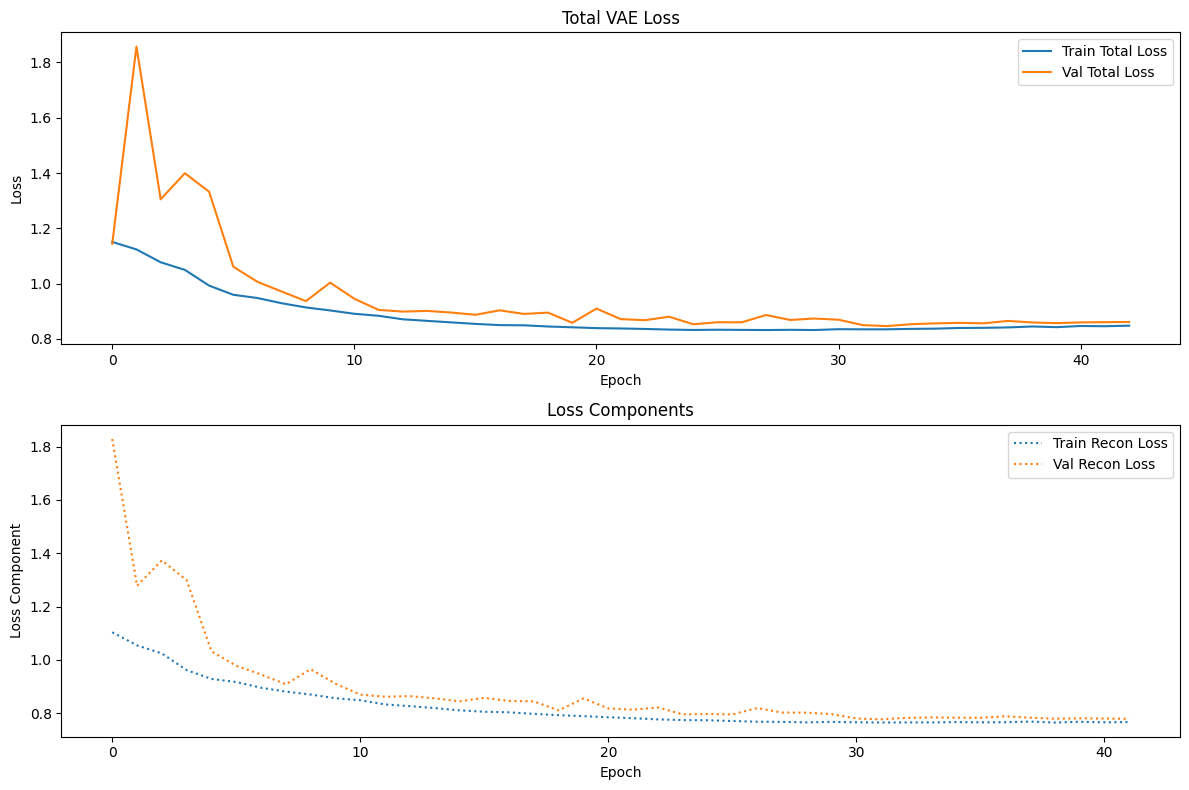

In [ ]:
# Plotting# 
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(history["train_losses"][2:], label="Train Total Loss")
plt.plot(history["val_losses"][2:], label="Val Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Total VAE Loss")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(history["train_recon_losses"][3:], label="Train Recon Loss", linestyle=':')
plt.plot(history["val_recon_losses"][3:], label="Val Recon Loss", linestyle=':')
#plt.plot(history["train_kl_losses"][3:], label="Train KL Loss", linestyle='--')
#plt.plot(history["val_kl_losses"][3:], label="Val KL Loss", linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Loss Component")
plt.title("Loss Components")
plt.legend()

plt.tight_layout()
plt.show()

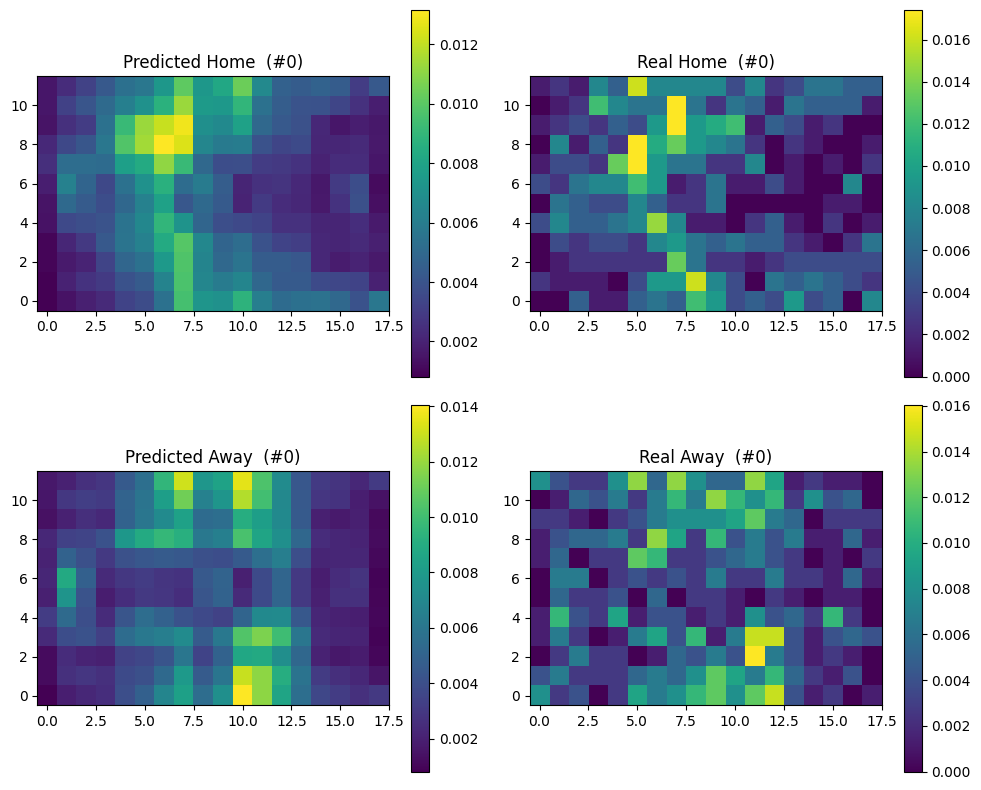

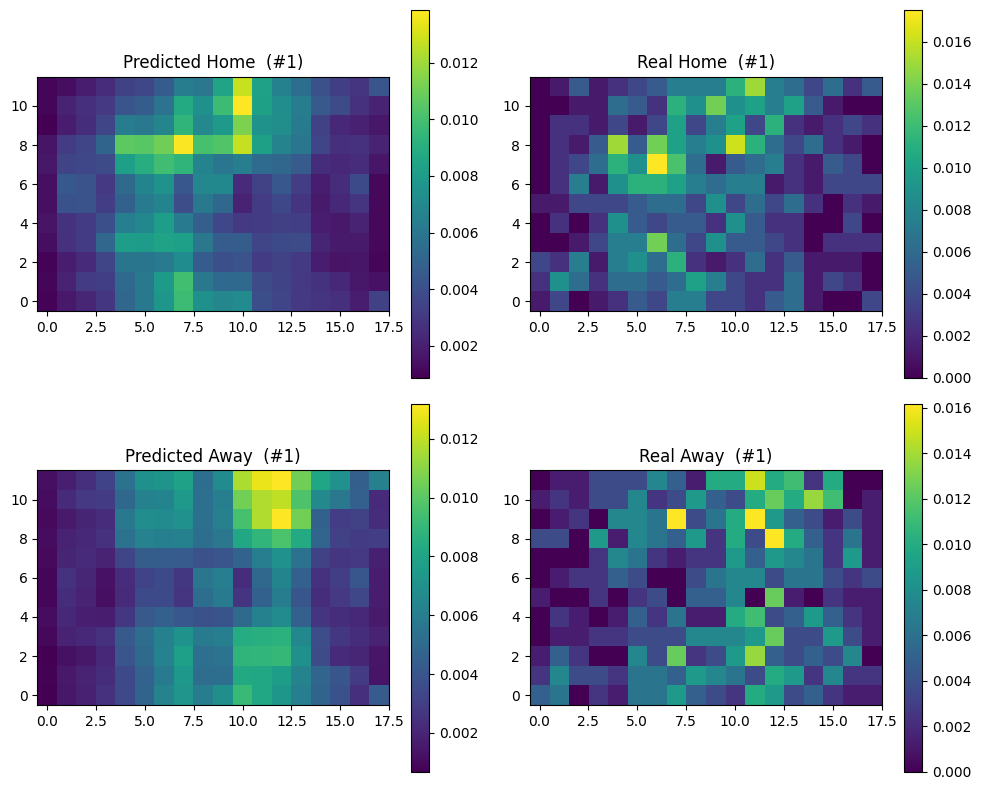

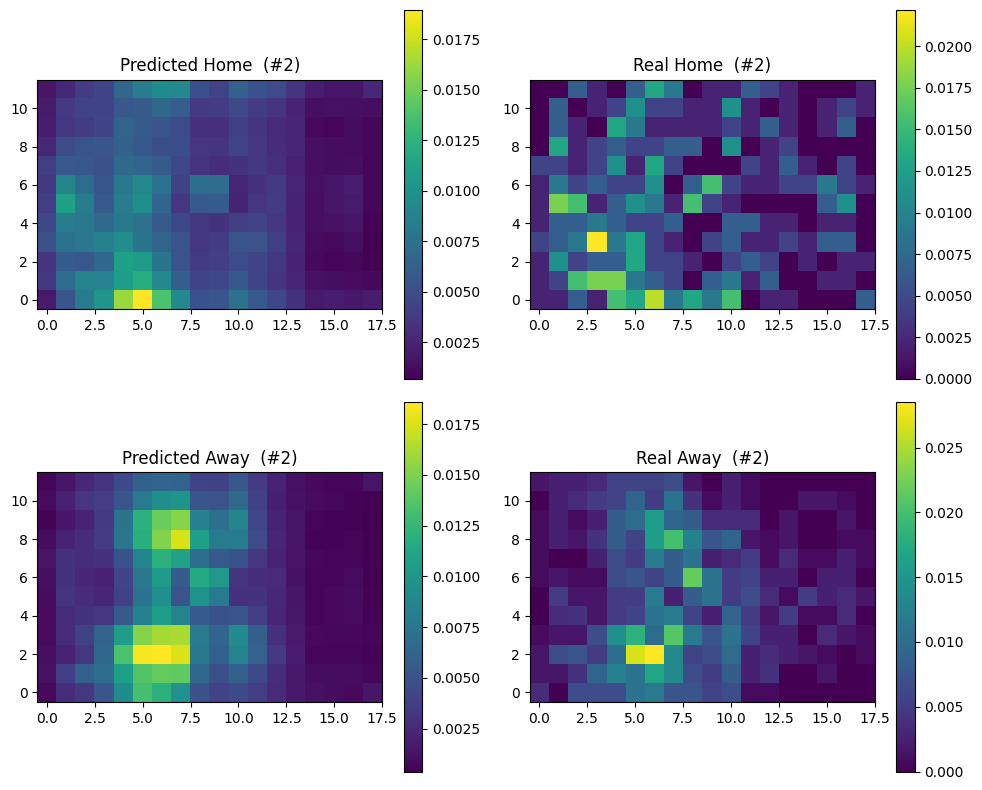

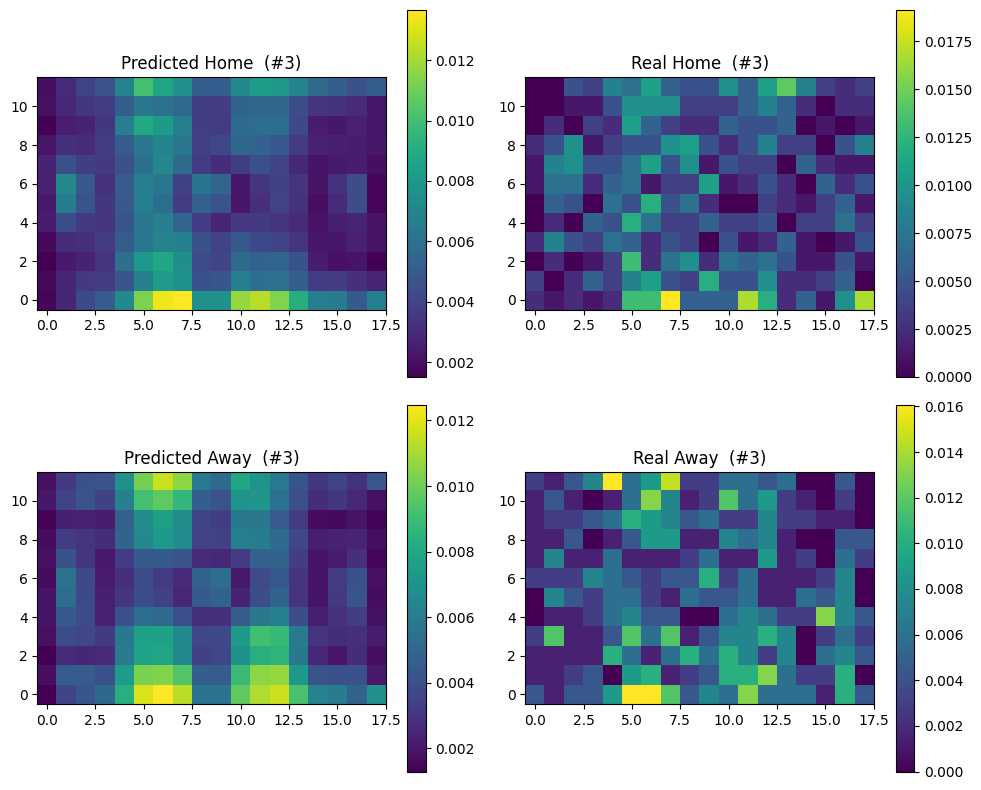

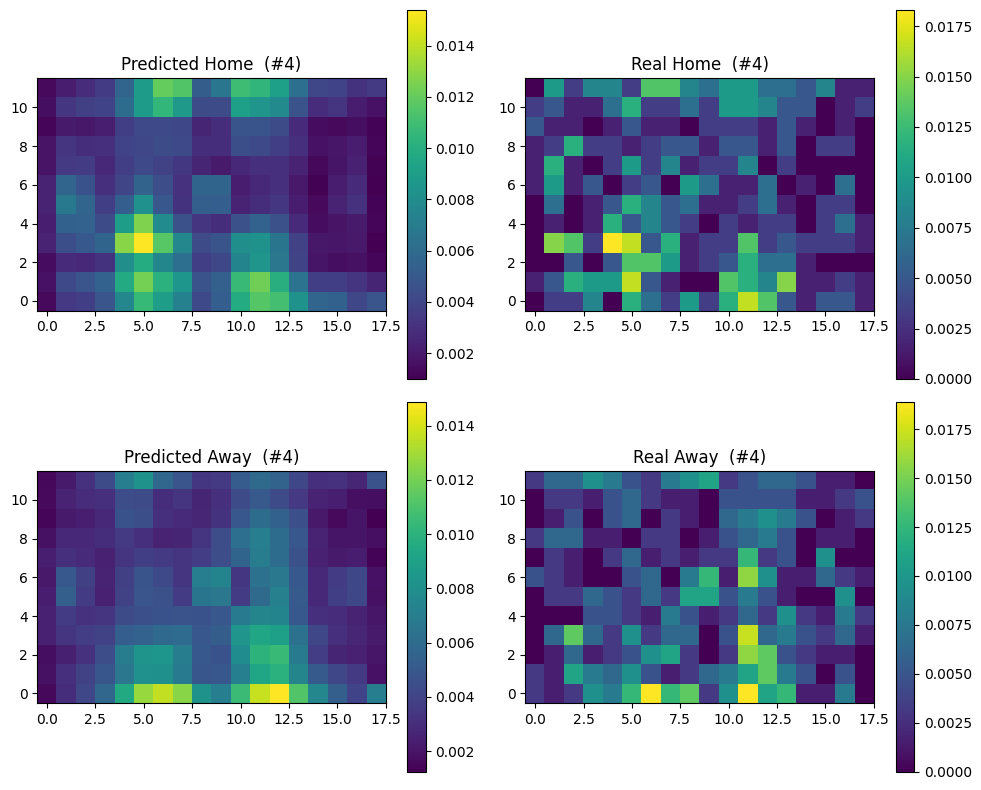

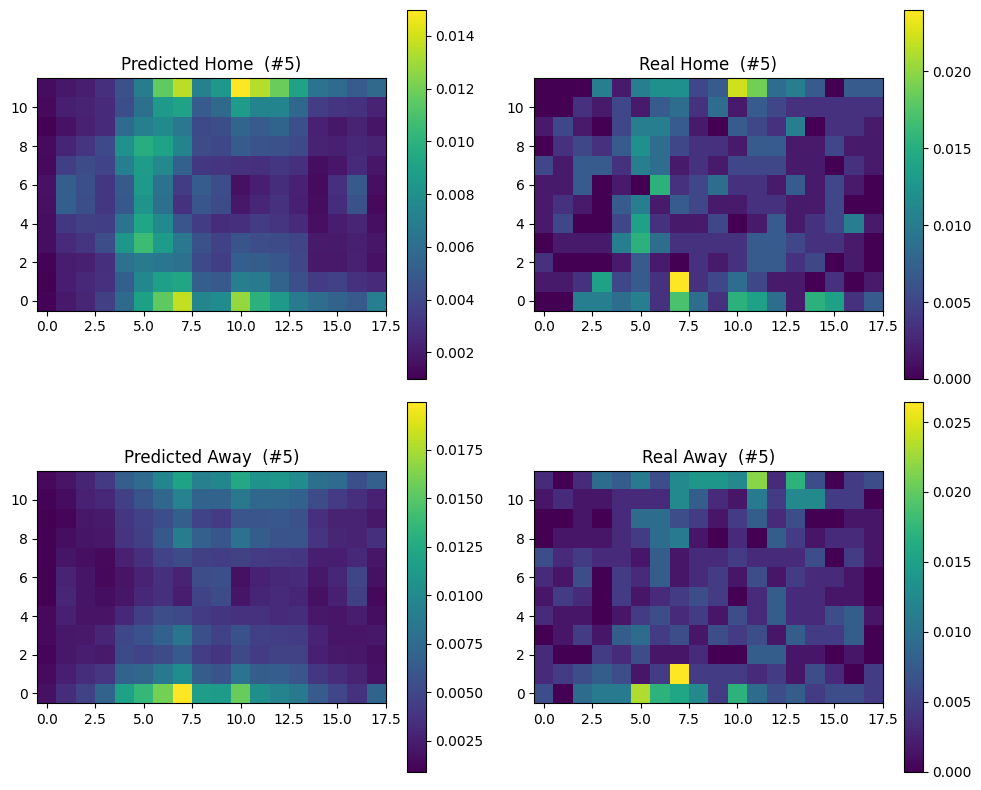

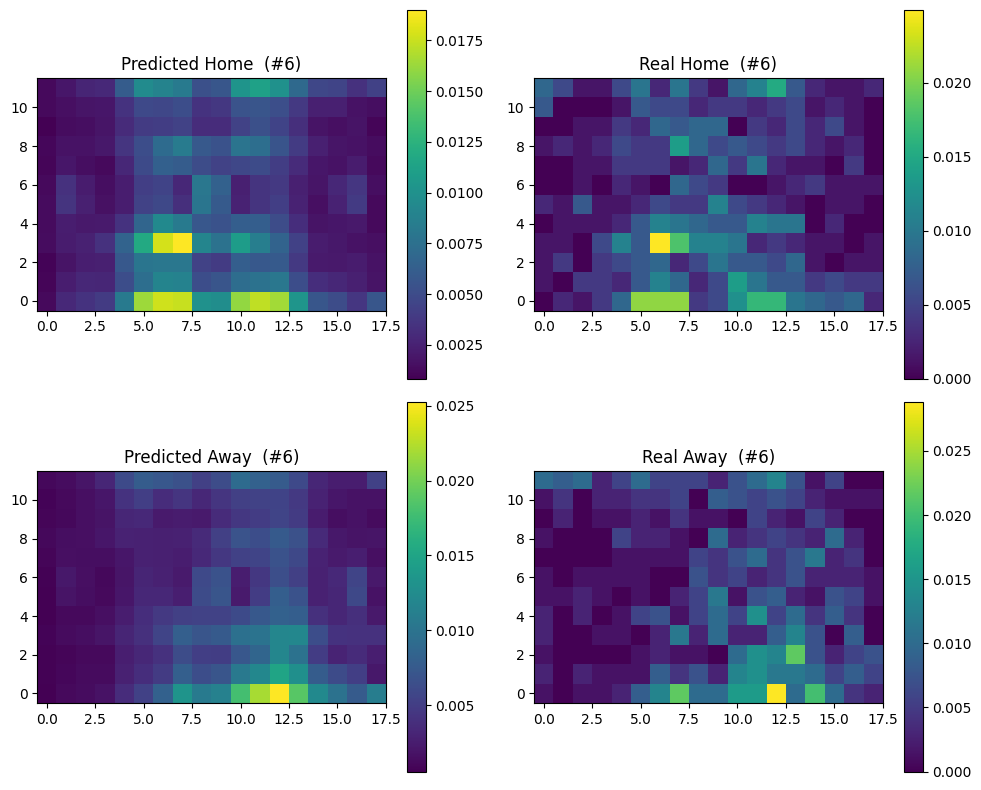

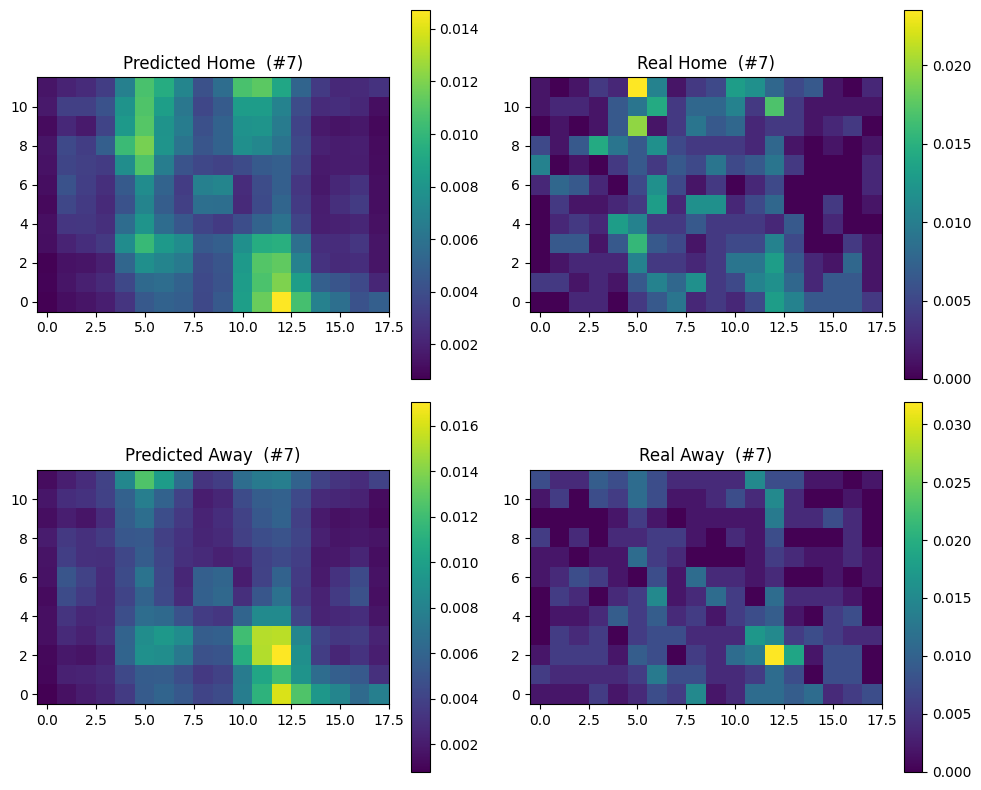

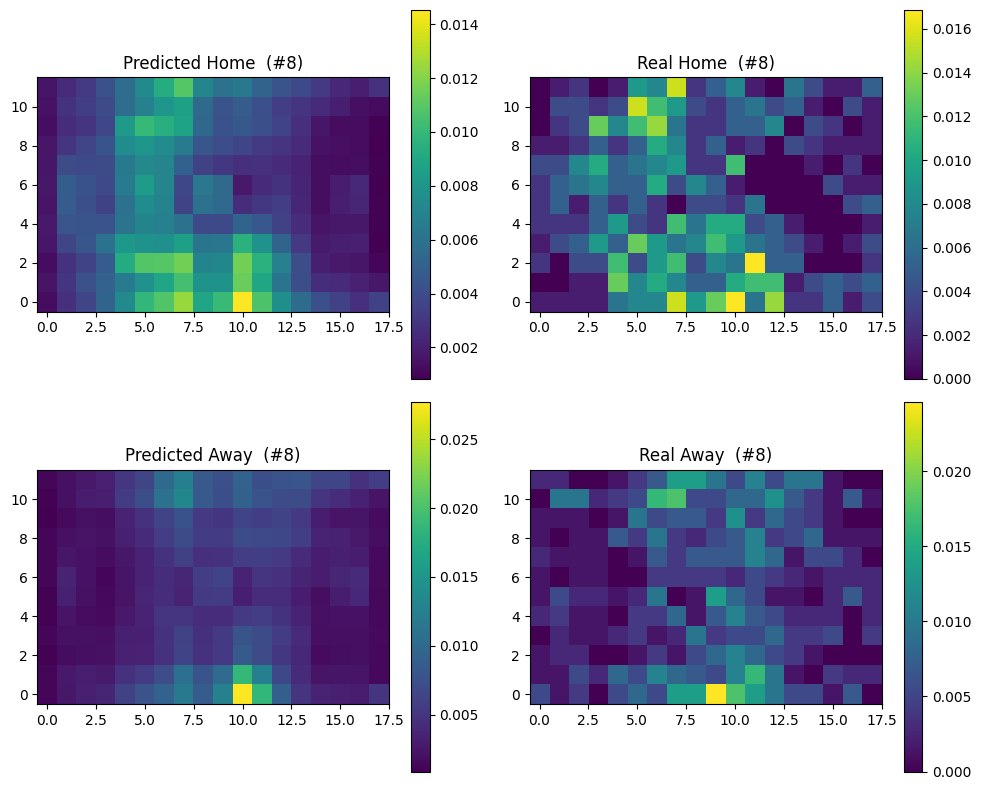

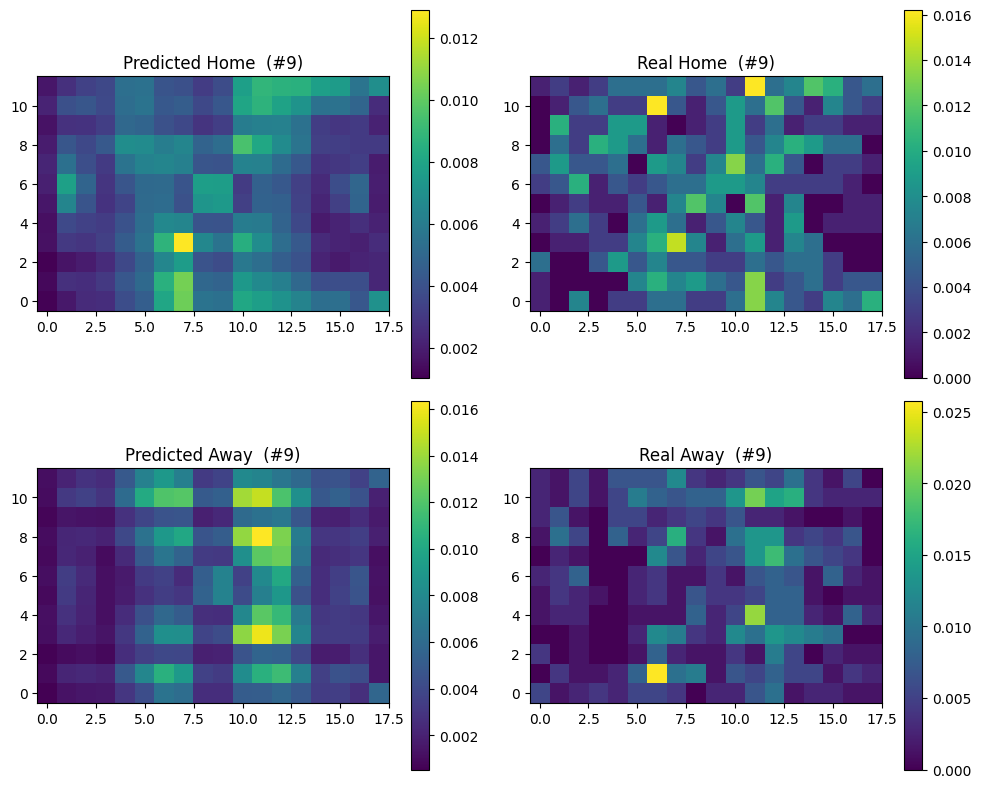

In [ ]:
device = torch.device('cuda')
visualize_test_samples(trained_vae, test_loader, n_y, n_x, num_samples=10, device=device)

In [ ]:
#torch.save(trained_vae.state_dict(), 'trained_vae_dirconvdec_GELU_130620251422.pth') 

In [ ]:
HeatmapVAE(
  (cnn_backbone): ConfigurableCoordCNN(
    (conv_blocks): Sequential(
      (0): CoordConv(
        (addcoords): AddCoords()
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (1): ReLU()
      (2): CoordConv(
        (addcoords): AddCoords()
        (conv): Conv2d(18, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (3): ReLU()
      (4): CoordConv(
        (addcoords): AddCoords()
        (conv): Conv2d(34, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (5): ReLU()
    )
    (fc): Linear(in_features=6912, out_features=64, bias=True)
    (activation_fc): ReLU()
  )
  (encoder_mlp): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=128, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=128, bias=True)
  (decoder_mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=216, bias=True)
    (5): Sigmoid()
  )
)
Model forward pass successful.
Input shape: torch.Size([4, 1, 12, 18])
Reconstruction shape: torch.Size([4, 1, 12, 18])
Reconstruction sum (should be ~1): 1.0000001192092896
Mu shape: torch.Size([4, 128])
Logvar shape: torch.Size([4, 128])

In [ ]:
--- Input x Verification (Epoch 1, Batch 0) ---
x.shape: torch.Size([128, 1, 12, 18])
x.dtype: torch.float32
x min: 0.000000, x max: 0.029453, x mean: 0.004630
Sums per heatmap (first 5): [0.99999994 1.         1.         1.         1.        ]
Are all sums per heatmap close to 1? True
-------------------------------------------------
Epoch 1/50: 
  Train Loss: 0.0116 (Recon: 0.0000, KL: 0.0116)
  Val Loss  : 0.0000 (Recon: 0.0000, KL: 0.0000)
  New best val loss: 0.0000. Checkpointing model.
Epoch 2/50: 
  Train Loss: 0.0000 (Recon: 0.0000, KL: 0.0000)
  Val Loss  : 0.0000 (Recon: 0.0000, KL: 0.0000)
  New best val loss: 0.0000. Checkpointing model.
Epoch 3/50: 
  Train Loss: 0.0000 (Recon: 0.0000, KL: 0.0000)
  Val Loss  : 0.0000 (Recon: 0.0000, KL: 0.0000)
  New best val loss: 0.0000. Checkpointing model.

In [ ]:
--- Latent Params (Epoch 1, Batch 0) ---
mu mean: 0.0005, mu std: 0.0559
logvar mean: 0.0086, logvar std: 0.0638
Calculated std mean: 1.0048
------------------------------------------
Epoch 1/50: 
  Train Loss: 0.0116 (Recon: 0.0000, KL: 0.0116)
  Val Loss  : 0.0000 (Recon: 0.0000, KL: 0.0000)
  New best val loss: 0.0000. Checkpointing model.
Epoch 2/50: 
  Train Loss: 0.0000 (Recon: 0.0000, KL: 0.0000)
  Val Loss  : 0.0000 (Recon: 0.0000, KL: 0.0000)
  New best val loss: 0.0000. Checkpointing model.
Epoch 3/50: 
  Train Loss: 0.0000 (Recon: 0.0000, KL: 0.0000)
  Val Loss  : 0.0000 (Recon: 0.0000, KL: 0.0000)
  New best val loss: 0.0000. Checkpointing model.
Epoch 4/50: 
  Train Loss: 0.0000 (Recon: 0.0000, KL: 0.0000)
  Val Loss  : 0.0000 (Recon: 0.0000, KL: 0.0000)
  New best val loss: 0.0000. Checkpointing model.
Epoch 5/50: 
  Train Loss: 0.0000 (Recon: 0.0000, KL: 0.0000)
  Val Loss  : 0.0000 (Recon: 0.0000, KL: 0.0000)
  New best val loss: 0.0000. Checkpointing model.
--- Latent Params (Epoch 6, Batch 0) ---
mu mean: 0.0000, mu std: 0.0000
logvar mean: 0.0000, logvar std: 0.0000
Calculated std mean: 1.0000
------------------------------------------
Epoch 6/50: 
  Train Loss: 0.0000 (Recon: 0.0000, KL: 0.0000)
  Val Loss  : 0.0000 (Recon: 0.0000, KL: 0.0000)

In [ ]:
Decoder - recon_img_before_norm: min=1.612e-01, max=8.152e-01, mean=4.960e-01, sum_example=1.072e+02
Decoder - recon_img_before_norm: min=4.745e-02, max=9.855e-01, mean=4.825e-01, sum_example=1.043e+02
Decoder - recon_img_before_norm: min=6.379e-02, max=9.842e-01, mean=4.886e-01, sum_example=1.054e+02
Decoder - recon_img_before_norm: min=5.854e-02, max=9.864e-01, mean=4.910e-01, sum_example=1.064e+02
Decoder - recon_img_before_norm: min=5.546e-02, max=9.907e-01, mean=4.909e-01, sum_example=1.061e+02

In [14]:
# ------------------------------------------------------------
# 1. Coord-Conv layer (Unchanged)
# ------------------------------------------------------------
class AddCoords(nn.Module):
    def forward(self, x):
        b, _, h, w = x.size()
        yy = torch.linspace(-1, 1, h, device=x.device, dtype=x.dtype)\
               .view(1, 1, h, 1).expand(b, 1, h, w)
        xx = torch.linspace(-1, 1, w, device=x.device, dtype=x.dtype)\
               .view(1, 1, 1, w).expand(b, 1, h, w)
        return torch.cat([x, xx, yy], dim=1)

class CoordConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1, stride=1, bias=True): # Added bias
        super().__init__()
        self.addcoords = AddCoords()
        self.conv      = nn.Conv2d(in_ch + 2, out_ch,
                                   kernel_size=kernel_size,
                                   padding=padding,
                                   stride=stride,
                                   bias=bias) # Use passed bias

    def forward(self, x):
        return self.conv(self.addcoords(x))

# ------------------------------------------------------------
# 2. Encoder CNN (ConfigurableCoordCNN with BatchNorm and robust dim tracking)
# ------------------------------------------------------------
class ConfigurableCoordCNN(nn.Module):
    def __init__(self, in_h: int, in_w: int, out_dim_cnn_features: int,
                 conv_channels: tuple[int, ...] = (8, 16, 32),
                 kernel_sizes: tuple[int | tuple[int, int], ...] = (3, 3, 3),
                 # ****** ADDED THESE PARAMETERS TO THE SIGNATURE ******
                 strides: tuple[int | tuple[int, int], ...] = (1, 1, 1),
                 paddings: tuple[str | int | tuple[int, int], ...] = ('same', 'same', 'same'),
                 pool_type: str | None = 'max', 
                 pool_factors: tuple[int | tuple[int, int], ...] = (2, 2, 2), 
                 pool_strides: tuple[int | tuple[int, int], ...] | None = None, 
                 # ******************************************************
                 activation_fn_class=nn.ReLU,
                 use_batchnorm: bool = True):
        super().__init__()
        
        num_blocks = len(conv_channels)
        # ****** UPDATED VALIDATION TO INCLUDE NEW PARAMS ******
        if not (len(kernel_sizes) == num_blocks and \
                len(strides) == num_blocks and \
                len(paddings) == num_blocks and \
                len(pool_factors) == num_blocks):
            raise ValueError("All conv config lists (channels, kernels, strides, paddings, pools) must have the same length.")
        if pool_strides is not None and len(pool_strides) != num_blocks:
            raise ValueError("pool_strides, if provided, must have the same length as other conv_config lists.")
        # ******************************************************

        blocks = []
        current_channels = 1
        current_h, current_w = in_h, in_w # Use different names
        
        activation_fn = activation_fn_class()

        for i in range(num_blocks):
            k = kernel_sizes[i]
            s = strides[i] # Use the passed stride
            pad = paddings[i] # Use the passed padding
            p_factor = pool_factors[i]
            p_s = pool_strides[i] if pool_strides else p_factor # Use the passed pool_stride
            out_c = conv_channels[i]
            
            # Convolutional Layer
            conv_layer = CoordConv(current_channels, out_c, kernel_size=k, 
                                   padding=pad, stride=s, bias=not use_batchnorm) # Pass s and pad
            blocks.append(conv_layer)
            # Get output shape from conv_layer for dimension tracking
            with torch.no_grad():
                dummy_input = torch.randn(1, current_channels, current_h, current_w)
                # Need a helper for CoordConv's internal conv or simplify CoordConv for shape inference
                # For now, let's assume the internal nn.Conv2d is what we care about for shape
                # This requires that CoordConv's self.conv is accessible or a shape_inference method
                # The dummy_input_for_conv helper addresses this
                dummy_output_shape = conv_layer.conv(dummy_input_for_conv(conv_layer, dummy_input)).shape
            current_h, current_w = dummy_output_shape[-2], dummy_output_shape[-1]

            if use_batchnorm:
                blocks.append(nn.BatchNorm2d(out_c))
            blocks.append(activation_fn)
            
            # Pooling Layer
            if pool_type and (p_factor > 1 if isinstance(p_factor, int) else any(f > 1 for f in p_factor if isinstance(f, int))): # Check if pooling is effective
                if pool_type.lower() == 'max':
                    pool_layer_instance = nn.MaxPool2d(kernel_size=p_factor, stride=p_s)
                elif pool_type.lower() == 'avg':
                    pool_layer_instance = nn.AvgPool2d(kernel_size=p_factor, stride=p_s)
                else:
                    raise ValueError(f"Unsupported pool_type: {pool_type}")
                blocks.append(pool_layer_instance)
                with torch.no_grad():
                    dummy_input_for_pool = torch.randn(1, out_c, current_h, current_w)
                    dummy_output_shape_pool = pool_layer_instance(dummy_input_for_pool).shape
                current_h, current_w = dummy_output_shape_pool[-2], dummy_output_shape_pool[-1]
            
            current_channels = out_c
            if current_h < 1 or current_w < 1:
                raise ValueError(f"Spatial dimensions ({current_h}x{current_w}) reduced to <1 after block {i}.")

        self.conv_blocks = nn.Sequential(*blocks)
        self.flattened_size = current_channels * current_h * current_w
        if self.flattened_size == 0:
            raise ValueError("Flattened size is 0.")
            
        self.fc = nn.Linear(self.flattened_size, out_dim_cnn_features)
        self.activation_fc = activation_fn_class()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_blocks(x)
        x = x.flatten(1)
        x = self.fc(x)
        x = self.activation_fc(x)
        return x

# Helper function (should be defined globally or as a static method if preferred)
def dummy_input_for_conv(coord_conv_layer: CoordConv, actual_input: torch.Tensor) -> torch.Tensor:
    b, _, h, w = actual_input.size()
    dummy_conv_input = torch.randn(b, coord_conv_layer.conv.in_channels, h, w, 
                                   device=actual_input.device, dtype=actual_input.dtype)
    return dummy_conv_input
# ------------------------------------------------------------
# 3. Decoder Implementations (Outputting Logits)
# ------------------------------------------------------------

class ConvolutionalDecoder(nn.Module): # Using ConvTranspose2d
    def __init__(self, latent_dim: int, output_h: int, output_w: int, 
                 initial_h: int = 3, initial_w: int = 4, 
                 decoder_channels: list = [128, 64], 
                 activation_fn_class=nn.ReLU,
                 use_batchnorm: bool = True):
        super().__init__()
        self.initial_h = initial_h
        self.initial_w = initial_w
        self.use_batchnorm = use_batchnorm
        activation_fn = activation_fn_class()

        fc_out_features = decoder_channels[0] * initial_h * initial_w
        self.fc = nn.Linear(latent_dim, fc_out_features)
        
        layers = []
        if self.use_batchnorm:
            layers.append(nn.BatchNorm1d(fc_out_features))
        layers.append(activation_fn)
        self.fc_post_process = nn.Sequential(*layers)
        
        self.conv_transpose1_in_channels = decoder_channels[0]
        self.conv_transpose1 = nn.ConvTranspose2d(
            decoder_channels[0], decoder_channels[1],
            kernel_size=(4, 3), stride=2, padding=(1, 0), bias=not self.use_batchnorm
        )
        
        layers_conv1 = []
        if self.use_batchnorm:
            layers_conv1.append(nn.BatchNorm2d(decoder_channels[1]))
        layers_conv1.append(activation_fn)
        self.post_conv1 = nn.Sequential(*layers_conv1)

        self.conv_transpose2 = nn.ConvTranspose2d(
            decoder_channels[1], 1, kernel_size=4, stride=2, padding=1, bias=True # Final layer, bias=True
        )

    def forward(self, z):
        x = self.fc(z)
        x = self.fc_post_process(x)
        x = x.view(-1, self.conv_transpose1_in_channels, self.initial_h, self.initial_w)
        
        x = self.conv_transpose1(x)
        x = self.post_conv1(x)
        
        x = self.conv_transpose2(x) # Output logits (B, 1, H, W)
        return x

class PixelShuffleDecoder(nn.Module):
    def __init__(self, latent_dim, output_h, output_w,
                 initial_h_before_shuffle, initial_w_before_shuffle, upscale_factor,
                 mlp_hidden_dims=[256], fc_out_channels=64,   
                 conv_hidden_channels=[32], activation_fn_class=nn.ReLU,
                 use_batchnorm: bool = True):
        super().__init__()
        self.initial_h_before_shuffle = initial_h_before_shuffle
        self.initial_w_before_shuffle = initial_w_before_shuffle
        self.upscale_factor = upscale_factor
        self.use_batchnorm = use_batchnorm
        self.fc_out_channels = fc_out_channels # Stored for reshape
        activation_fn = activation_fn_class()

        # MLP part
        mlp_layers_list = []
        current_dim = latent_dim
        for i, h_dim in enumerate(mlp_hidden_dims):
            mlp_layers_list.append(nn.Linear(current_dim, h_dim))
            if self.use_batchnorm:
                mlp_layers_list.append(nn.BatchNorm1d(h_dim))
            mlp_layers_list.append(activation_fn)
            current_dim = h_dim
        
        flat_spatial_dim = fc_out_channels * initial_h_before_shuffle * initial_w_before_shuffle
        mlp_layers_list.append(nn.Linear(current_dim, flat_spatial_dim))
        if self.use_batchnorm:
            mlp_layers_list.append(nn.BatchNorm1d(flat_spatial_dim))
        # Activation after the full MLP (including final projection and its BN) will be applied in forward
        self.mlp = nn.Sequential(*mlp_layers_list)
        self.mlp_final_activation = activation_fn # To apply after reshape

        # Convolutional part before PixelShuffle
        conv_ops_list = []
        current_channels_conv = fc_out_channels
        for hidden_c in conv_hidden_channels:
            conv_ops_list.append(nn.Conv2d(current_channels_conv, hidden_c, kernel_size=3, padding=1, bias=not self.use_batchnorm))
            if self.use_batchnorm:
                conv_ops_list.append(nn.BatchNorm2d(hidden_c))
            conv_ops_list.append(activation_fn)
            current_channels_conv = hidden_c
        
        final_conv_out_channels = 1 * (upscale_factor ** 2) # Target 1 channel after shuffle
        conv_ops_list.append(nn.Conv2d(current_channels_conv, final_conv_out_channels, kernel_size=3, padding=1, bias=True)) # Final conv, bias=True
        self.conv_blocks = nn.Sequential(*conv_ops_list)
        
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor)

    def forward(self, z):
        x = self.mlp(z)
        x = self.mlp_final_activation(x) 
        x = x.view(-1, self.fc_out_channels, self.initial_h_before_shuffle, self.initial_w_before_shuffle)
        
        x = self.conv_blocks(x) 
        x = self.pixel_shuffle(x) # Outputs (B, 1, H, W) logits
        return x

class DirectSpatialDecoder(nn.Module): # Renamed for clarity in my mind, was DirectConvDecoderOption2
    def __init__(self, 
                 latent_dim: int, 
                 output_h: int, 
                 output_w: int,
                 initial_channels: int = 64, 
                 # ****** CORRECTED PARAMETERS HERE ******
                 conv_hidden_channels: tuple[int, ...] = (32, 16), 
                 conv_kernel_sizes: tuple[int, ...] = (3, 3), # Kernel sizes for hidden conv layers
                 final_conv_kernel_size: int = 3, # Kernel size for the last conv layer
                 # **************************************
                 activation_fn_class=nn.ReLU, 
                 use_batchnorm: bool = True):
        super().__init__()
        self.output_h = output_h
        self.output_w = output_w
        self.initial_channels = initial_channels # For reshape
        self.use_batchnorm = use_batchnorm
        
        activation_fn = activation_fn_class() # Instantiate

        # 1. Project latent z to match InitialChannels * H * W
        fc_out_features = initial_channels * output_h * output_w
        self.fc_to_spatial = nn.Linear(latent_dim, fc_out_features)
        
        # Optional: BatchNorm and Activation after FC before reshape
        fc_post_layers_list = []
        if self.use_batchnorm:
            #fc_post_layers_list.append(nn.Linear(fc_out_features, fc_out_features))
            fc_post_layers_list.append(nn.BatchNorm1d(fc_out_features))
        fc_post_layers_list.append(activation_fn)
        self.fc_post_process = nn.Sequential(*fc_post_layers_list)
        
        # 2. Convolutional layers operating at full HxW resolution
        conv_layers_list = []
        current_c = initial_channels
        
        # ****** VALIDATION FOR CORRECTED PARAMETERS ******
        if len(conv_kernel_sizes) != len(conv_hidden_channels):
            raise ValueError("DirectSpatialDecoder: conv_kernel_sizes list must have same length as conv_hidden_channels")
        # ************************************************

        for i, hidden_c in enumerate(conv_hidden_channels):
            k = conv_kernel_sizes[i] # Use the specific kernel size for this layer
            conv_layers_list.append(nn.Conv2d(current_c, hidden_c, 
                                              kernel_size=k, padding='same', 
                                              bias=not self.use_batchnorm))
            if self.use_batchnorm:
                conv_layers_list.append(nn.BatchNorm2d(hidden_c))
            conv_layers_list.append(activation_fn)
            current_c = hidden_c
        
        # Final convolutional layer to output 1 channel (logits)
        conv_layers_list.append(nn.Conv2d(current_c, 1, # Output 1 channel
                                          kernel_size=final_conv_kernel_size, padding='same', 
                                          bias=True)) # Final layer, usually keep bias
        self.conv_layers = nn.Sequential(*conv_layers_list)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # z: (B, latent_dim)
        x = self.fc_to_spatial(z)       # (B, initial_channels * H * W)
        x = self.fc_post_process(x)     # Apply BN1d and Activation
        
        # Reshape to (B, initial_channels, H, W)
        x = x.view(-1, self.initial_channels, self.output_h, self.output_w)
        
        # Pass through convolutional layers
        x = self.conv_layers(x)         # (B, 1, H, W) - these are the logits
        return x

# ------------------------------------------------------------
# 4. VAE Model with Softmax Decoder Output
# ------------------------------------------------------------
class HeatmapVAE(nn.Module):
    def __init__(self,
                 in_h: int, in_w: int, latent_dim: int = 16,
                 # Encoder CNN
                 cnn_out_features: int = 64,
                 cnn_conv_channels: tuple[int, ...] = (16, 32, 32),
                 cnn_kernel_sizes: tuple[int | tuple[int, int], ...] = (3, 3, 3),
                 # ****** ADDED THESE ENCODER CNN PARAMETERS HERE ******
                 cnn_strides: tuple[int | tuple[int, int], ...] = (1, 1, 1),
                 cnn_paddings: tuple[str | int | tuple[int, int], ...] = ('same', 'same', 'same'),
                 cnn_pool_type: str | None = 'max',
                 cnn_pool_factors: tuple[int | tuple[int, int], ...] = (1, 1, 1), 
                 cnn_pool_strides: tuple[int | tuple[int, int], ...] | None = None,
                 # ******************************************************
                 cnn_use_batchnorm: bool = True,
                 # Encoder MLP
                 encoder_hidden_dims: tuple[int, ...] = (128,),
                 # Decoder
                 decoder_type: str = "mlp", 
                 use_batchnorm_decoder: bool = True,
                 # MLP Decoder specific
                 decoder_mlp_hidden_dims: tuple[int, ...] = (128, 256),
                 # ConvTranspose Decoder specific
                 decoder_ct_initial_dims: tuple[int, int] = (3,4),
                 decoder_ct_channels: tuple[int, ...] = (128, 64, 1), 
                 decoder_ct_kernel_sizes: tuple[int | tuple[int, int], ...] = ((4,3), 4, 4), 
                 decoder_ct_strides: tuple[int | tuple[int, int], ...] = (2, 2, 1), 
                 decoder_ct_paddings: tuple[int | tuple[int, int], ...] = ((1,0), 1, 1), 
                 decoder_ct_output_paddings: tuple[int | tuple[int, int], ...] = (0,0,0), 
                 # PixelShuffle Decoder specific
                 ps_upscale_factor: int = 2,
                 ps_initial_h_factor_divisor: int = 2, 
                 ps_initial_w_factor_divisor: int = 2, 
                 ps_mlp_hidden_dims: tuple[int, ...] = (256,),
                 ps_fc_out_channels: int = 64,
                 ps_conv_hidden_channels: tuple[int, ...] = (32,),
                 ps_conv_kernel_sizes: tuple[int, ...] = (3,),
                 # DirectSpatialDecoder specific
                 dc_initial_channels: int = 64,
                 dc_conv_hidden_channels: tuple[int, ...] = (32, 16),
                 dc_conv_kernel_sizes: tuple[int, ...] = (3,3),
                 dc_final_conv_kernel_size: int = 3,
                 # General
                 activation_fn_class=nn.ReLU,
                 softmax_temperature: float = 1.0):
        super().__init__()
        self.in_h = in_h
        self.in_w = in_w
        self.flat_dim = in_h * in_w
        self.latent_dim = latent_dim
        self.decoder_type = decoder_type
        self.softmax_temperature = softmax_temperature

        # ------------- Encoder CNN Backbone -------------
        self.cnn_backbone = ConfigurableCoordCNN(
            in_h, in_w, cnn_out_features,
            conv_channels=cnn_conv_channels, 
            kernel_sizes=cnn_kernel_sizes,
            # ****** PASSING THE NEW PARAMETERS HERE ******
            strides=cnn_strides, 
            paddings=cnn_paddings,
            pool_type=cnn_pool_type, 
            pool_factors=cnn_pool_factors, 
            pool_strides=cnn_pool_strides,
            # *********************************************
            activation_fn_class=activation_fn_class, 
            use_batchnorm=cnn_use_batchnorm
        )

        # ... (rest of the HeatmapVAE __init__ method remains the same) ...
        # ------------- Encoder MLP (processes CNN features) -------------
        encoder_mlp_layers = []
        current_dim_enc = cnn_out_features
        activation_fn_enc = activation_fn_class()
        for h_dim in encoder_hidden_dims:
            encoder_mlp_layers.append(nn.Linear(current_dim_enc, h_dim))
            encoder_mlp_layers.append(activation_fn_enc)
            current_dim_enc = h_dim
        self.encoder_mlp = nn.Sequential(*encoder_mlp_layers)
        self.fc_mu = nn.Linear(current_dim_enc, latent_dim)
        self.fc_logvar = nn.Linear(current_dim_enc, latent_dim)

        # ------------- Decoder (Outputs Logits) -------------
        if self.decoder_type == "mlp":
            decoder_mlp_list = []
            current_dim_dec = latent_dim
            activation_fn_dec = activation_fn_class() 
            for h_dim in decoder_mlp_hidden_dims:
                decoder_mlp_list.append(nn.Linear(current_dim_dec, h_dim))
                if use_batchnorm_decoder:
                    decoder_mlp_list.append(nn.BatchNorm1d(h_dim))
                decoder_mlp_list.append(activation_fn_dec)
                current_dim_dec = h_dim
            decoder_mlp_list.append(nn.Linear(current_dim_dec, self.flat_dim, bias=True))
            self.decoder = nn.Sequential(*decoder_mlp_list)

        elif self.decoder_type == "conv_transpose":
            self.decoder = ConvolutionalDecoder(
                latent_dim=latent_dim, output_h=in_h, output_w=in_w,
                initial_h=decoder_ct_initial_dims[0], initial_w=decoder_ct_initial_dims[1],
                decoder_channels=decoder_ct_channels, 
                kernel_sizes_ct=decoder_ct_kernel_sizes, strides_ct=decoder_ct_strides,
                paddings_ct=decoder_ct_paddings, output_paddings_ct=decoder_ct_output_paddings,
                activation_fn_class=activation_fn_class, use_batchnorm=use_batchnorm_decoder
            )

        elif self.decoder_type == "pixel_shuffle":
            initial_h_ps = in_h // ps_initial_h_factor_divisor
            initial_w_ps = in_w // ps_initial_w_factor_divisor
            if initial_h_ps * ps_upscale_factor != in_h or initial_w_ps * ps_upscale_factor != in_w :
                 print(f"Warning: PixelShuffle output {initial_h_ps*ps_upscale_factor}x{initial_w_ps*ps_upscale_factor} might not match target {in_h}x{in_w} with current factors.")

            self.decoder = PixelShuffleDecoder(
                latent_dim=latent_dim, output_h=in_h, output_w=in_w,
                initial_h_before_shuffle=initial_h_ps, initial_w_before_shuffle=initial_w_ps,
                upscale_factor=ps_upscale_factor,
                mlp_hidden_dims=ps_mlp_hidden_dims, fc_out_channels=ps_fc_out_channels,
                conv_hidden_channels=ps_conv_hidden_channels, conv_kernel_sizes=ps_conv_kernel_sizes,
                activation_fn_class=activation_fn_class, use_batchnorm=use_batchnorm_decoder
            )
        elif self.decoder_type == "direct_spatial_conv": # Matched your string "direct_conv"
            self.decoder = DirectSpatialDecoder( 
                latent_dim=latent_dim, output_h=in_h, output_w=in_w,
                initial_channels=dc_initial_channels, 
                conv_hidden_channels=dc_conv_hidden_channels,
                conv_kernel_sizes=dc_conv_kernel_sizes, 
                final_conv_kernel_size=dc_final_conv_kernel_size,
                activation_fn_class=activation_fn_class, 
                use_batchnorm=use_batchnorm_decoder
            )
        else:
            raise ValueError(f"Unknown decoder_type: {self.decoder_type}")

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        cnn_features = self.cnn_backbone(x)
        h_enc = self.encoder_mlp(cnn_features)
        mu = self.fc_mu(h_enc)
        logvar = self.fc_logvar(h_enc)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode_with_softmax(self, z: torch.Tensor) -> torch.Tensor:
        raw_spatial_logits = self.decoder(z)
        if raw_spatial_logits.dim() == 4:
            batch_size = raw_spatial_logits.size(0)
            logits_flat = raw_spatial_logits.view(batch_size, -1) 
        elif raw_spatial_logits.dim() == 2:
            logits_flat = raw_spatial_logits
        else:
            raise ValueError(f"Decoder output unexpected shape: {raw_spatial_logits.shape}")

        probabilities_flat = F.softmax(logits_flat / self.softmax_temperature, dim=1)
        output_img = probabilities_flat.view(-1, 1, self.in_h, self.in_w)
        return output_img

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode_with_softmax(z)
        return x_recon, mu, logvar